1. Import Library

In [ ]:
import pandas as pd

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# SMOTE
from imblearn.over_sampling import SMOTE

# KNN
from sklearn.neighbors import KNeighborsClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


2. Load Dataset

In [3]:
# Membaca dataset stroke
df = pd.read_csv("stroke.csv")

# Menampilkan 5 data pertama
df.head(5)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


3.Pra-processing Data(Pembersihan & Transformasi)

In [4]:
# Menghapus kolom id
df = df.drop("id", axis=1)

# Mengisi missing value pada bmi dengan rata-rata
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

# Encoding data kategorikal
label_encoder = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type',
                    'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Data setelah preprocessing:")
print(df.head())


Data setelah preprocessing:
   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          2   
1       0  61.0             0              0             1          3   
2       1  80.0             0              1             1          2   
3       0  49.0             0              0             1          2   
4       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level        bmi  smoking_status  stroke  
0               1             228.69  36.600000               1       1  
1               0             202.21  28.893237               2       1  
2               0             105.92  32.500000               2       1  
3               1             171.23  34.400000               3       1  
4               0             174.12  24.000000               2       1  


C:\Users\MSI_MODERN\AppData\Local\Temp\ipykernel_3464\4071711895.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


4.Pembagian Data Latih dan Data Uji

In [5]:
#Pemisahan fitur dan target
X = df.drop("stroke", axis=1)   # fitur
y = df["stroke"]                # target

#Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


Jumlah data training: 4088
Jumlah data testing: 1022


5.Normalisasi Data

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


6.Penerapan Teknik SMOTE(HANYA pada data training)

In [7]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Distribusi setelah SMOTE:")
print(pd.Series(y_train).value_counts())

Distribusi setelah SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64


7.Penerapan Algoritma K-NN

In [8]:
# Misalnya K = 5
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)


7.Evaluasi Kinerja Model

In [9]:
# Akurasi
accuracy = accuracy_score(y_test, y_pred)
print("Akurasi Model:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Akurasi Model: 0.8062622309197651

Confusion Matrix:
[[808 164]
 [ 34  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       972
           1       0.09      0.32      0.14        50

    accuracy                           0.81      1022
   macro avg       0.52      0.58      0.51      1022
weighted avg       0.92      0.81      0.85      1022



<Figure size 640x480 with 0 Axes>

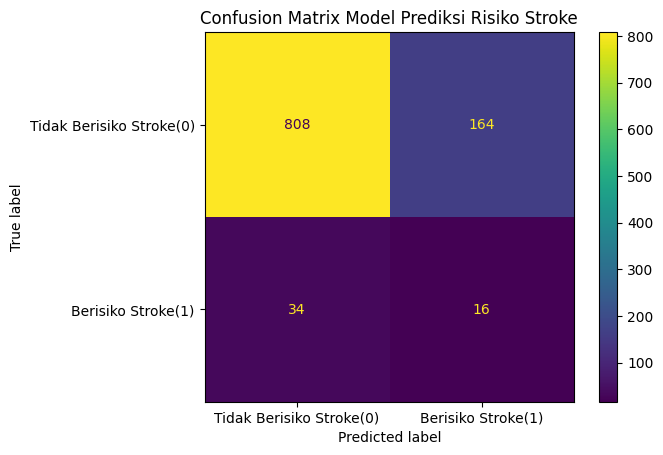

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Tidak Berisiko Stroke(0)", "Berisiko Stroke(1)"])
plt.figure()
disp.plot()
plt.title("Confusion Matrix Model Prediksi Risiko Stroke")
plt.show()


In [97]:
import pickle

with open('model_knn_stroke.pkl', 'wb') as file:
    pickle.dump(knn, file)

# Simpan scaler
with open('scaler_stroke.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!
